# Nettoyage du Dataset Anime (PySpark & Matplotlib)

Ce notebook documente l'analyse exploratoire, le traitement des valeurs manquantes (trous de données) et des valeurs aberrantes (outliers) pour le dataset `anime_dataset.csv` en utilisant **PySpark** et **Matplotlib**.

## Objectifs :
0. **Analyser les statistiques descriptives globales** du dataset (types, distributions, percentiles, variables catégorielles).
1. **Identifier les données manquantes** et définir une stratégie d'imputation cohérente.
2. **Identifier les valeurs aberrantes** (distinction entre anomalies réelles de saisie et valeurs extrêmes statistiquement atypiques mais valides).
3. **Nettoyer les données** en utilisant PySpark.
4. **Visualiser les résultats** avant et après le nettoyage.
5. **Sauvegarder le jeu de données nettoyé**.


In [34]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Initialiser la session Spark
spark = SparkSession.builder \
                    .appName("Anime Data Cleaning") \
                    .getOrCreate()

# Réduire les logs Spark pour une meilleure lisibilité dans Jupyter
spark.sparkContext.setLogLevel("ERROR")

# Activer l'évaluation dynamique pour un affichage propre des DataFrames
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

# Charger les données avec les options pour gérer les sauts de ligne dans les champs de texte
df = spark.read \
          .option("multiLine", True) \
          .option("escape", '"') \
          .csv("data/anime_dataset.csv", header=True, inferSchema=True)

print(f"Dimensions du dataset original : {df.count()} lignes, {len(df.columns)} colonnes.")


Dimensions du dataset original : 4985 lignes, 32 colonnes.


## 0. Statistiques Descriptives Globales

Avant toute manipulation, nous examinons la structure et les caractéristiques statistiques brutes du dataset :
1. **Schéma** : types de colonnes inférés par PySpark.
2. **Statistiques descriptives** (count, mean, stddev, min, max) sur les colonnes numériques via `df.describe()`.
3. **Percentiles** (Q1, médiane, Q3, P90, P99) pour les variables clés.
4. **Distributions catégorielles** : répartition des animés par `format`, `status`, `rating` et `season`.

In [35]:
# 0.1 Schéma du dataset
print("=== Schéma du dataset ===")
df.printSchema()

# 0.2 Statistiques descriptives globales (colonnes numériques)
num_cols_stats = ["score", "episodes", "duration_min", "members", "favorites", "scored_by", "rank", "start_year"]
print("\n=== Statistiques descriptives (count / mean / stddev / min / max) ===")
df.describe(num_cols_stats).show(truncate=False)

# 0.3 Percentiles (Q1, médiane, Q3, P90, P99)
percentile_cols = ["score", "episodes", "duration_min", "members"]
quantile_levels = [0.25, 0.50, 0.75, 0.90, 0.99]
labels = ["Q1", "Médiane", "Q3", "P90", "P99"]

print("\n=== Percentiles clés ===")
pct_rows = []
for col in percentile_cols:
    vals = df.approxQuantile(col, quantile_levels, 0.01)
    pct_rows.append([col] + [f"{v:.2f}" if v is not None else "N/A" for v in vals])

pct_df = pd.DataFrame(pct_rows, columns=["Colonne"] + labels)
print(pct_df.to_string(index=False))

# 0.4 Distributions catégorielles
_n = df.count()
cat_cols = ["format", "status", "rating", "season"]
for col in cat_cols:
    print(f"\n=== Distribution par '{col}' ===")
    df.groupBy(col).count() \
      .withColumnRenamed("count", "nb_animes") \
      .withColumn("pourcentage", F.round(F.col("nb_animes") / _n * 100, 2)) \
      .orderBy(F.col("nb_animes").desc()) \
      .show(truncate=False)


=== Schéma du dataset ===
root
 |-- mal_id: integer (nullable = true)
 |-- title_romaji: string (nullable = true)
 |-- title_english: string (nullable = true)
 |-- title_native: string (nullable = true)
 |-- synonyms: string (nullable = true)
 |-- format: string (nullable = true)
 |-- status: string (nullable = true)
 |-- episodes: double (nullable = true)
 |-- duration_min: double (nullable = true)
 |-- start_year: double (nullable = true)
 |-- start_month: double (nullable = true)
 |-- start_day: double (nullable = true)
 |-- end_year: double (nullable = true)
 |-- end_month: double (nullable = true)
 |-- end_day: double (nullable = true)
 |-- season: string (nullable = true)
 |-- season_year: double (nullable = true)
 |-- source: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- is_adult: boolean (nullable = true)
 |-- score: double (nullable = true)
 |-- scored_by: double (nullable = true)
 |-- rank: double (nullable = true)
 |-- popularity_rank: integer (nullable

## 1. Analyse des valeurs manquantes (Trous de données)

Identifions d'abord le nombre de valeurs manquantes par colonne pour concevoir notre plan de nettoyage.


In [36]:
# Calculer le nombre de valeurs nulles par colonne en PySpark (une seule passe)
total_rows = df.count()
null_exprs = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
null_counts_row = df.select(null_exprs).collect()[0].asDict()

null_counts = []
for col_name, null_c in null_counts_row.items():
    if null_c > 0:
        pct = (null_c / total_rows) * 100
        null_counts.append((col_name, null_c, pct))

# Créer un DataFrame de résumé uniquement pour l'affichage de la donnée
missing_df = pd.DataFrame(null_counts, columns=["Colonne", "Valeurs Manquantes", "Pourcentage (%)"])
missing_df = missing_df.sort_values(by="Valeurs Manquantes", ascending=False).reset_index(drop=True)
missing_df

,Colonne,Valeurs Manquantes,Pourcentage (%)
0,season_year,1946,39.037111
1,season,1946,39.037111
2,synonyms,1688,33.861585
3,end_day,1438,28.846540
4,end_year,1438,28.846540
5,end_month,1438,28.846540
6,title_english,750,15.045135
7,tags,689,13.821464
8,rank,189,3.791374
9,episodes,86,1.725176


## 2. Analyse des valeurs aberrantes (Outliers)

Les valeurs aberrantes peuvent être de deux types :
1. **Erreurs de saisie / Incohérences logiques** (ex: date de fin antérieure à la date de début).
2. **Valeurs statistiques extrêmes mais valides** (ex: séries à très long cours comme *Doraemon* avec plus de 1700 épisodes).

### 2.1 Incohérences Temporelles
Vérifions si certaines dates de début sont postérieures aux dates de fin.


In [37]:
# Incohérence start > end
incoherent_dates = df.filter(
    (F.col("start_year") > F.col("end_year")) |
    ((F.col("start_year") == F.col("end_year")) & (F.col("start_month") > F.col("end_month"))) |
    ((F.col("start_year") == F.col("end_year")) & (F.col("start_month") == F.col("end_month")) & (F.col("start_day") > F.col("end_day")))
)

print(f"Nombre d'incohérences de date directes : {incoherent_dates.count()}")
if incoherent_dates.count() > 0:
    incoherent_dates.select("mal_id", "title_romaji", "start_year", "start_month", "end_year", "end_month").show()


Nombre d'incohérences de date directes : 1
+------+--------------------+----------+-----------+--------+---------+
|mal_id|        title_romaji|start_year|start_month|end_year|end_month|
+------+--------------------+----------+-----------+--------+---------+
| 10330|Bakugan Battle Br...|    2018.0|        9.0|  2018.0|      1.0|
+------+--------------------+----------+-----------+--------+---------+



### 2.2 Outliers Statistiques (IQR Method)
Utilisons l'écart interquartile (IQR) pour identifier les outliers sur les colonnes numériques : `episodes`, `duration_min`, `score`, et `members`.


In [38]:
num_cols = ["episodes", "duration_min", "score", "members"]

for col in num_cols:
    # Calculer Q1, Q3 et IQR
    quantiles = df.approxQuantile(col, [0.25, 0.75], 0.01)
    if len(quantiles) == 2:
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers_count = df.filter((F.col(col) < lower_bound) | (F.col(col) > upper_bound)).count()
        pct = (outliers_count / total_rows) * 100
        
        print(f"Colonne '{col}' : Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
        print(f"  Nombre d'outliers : {outliers_count} ({pct:.2f}%)\n")


Colonne 'episodes' : Q1=2.00, Q3=13.00, IQR=11.00
  Nombre d'outliers : 256 (5.14%)

Colonne 'duration_min' : Q1=23.00, Q3=25.00, IQR=2.00
  Nombre d'outliers : 1438 (28.85%)

Colonne 'score' : Q1=6.79, Q3=7.70, IQR=0.91
  Nombre d'outliers : 57 (1.14%)

Colonne 'members' : Q1=46322.00, Q3=220083.00, IQR=173761.00
  Nombre d'outliers : 541 (10.85%)



### 2.3 Examen des valeurs maximales et minimales
Regardons de plus près les extrêmes de `episodes` et `duration_min` pour voir si ce sont des erreurs ou des cas valides.


In [39]:
print("Top 5 animés avec le plus d'épisodes :")
df.orderBy(F.col("episodes").desc()).select("title_romaji", "episodes", "format").show(5)

print("Top 5 animés les plus longs (durée en minutes) :")
df.orderBy(F.col("duration_min").desc()).select("title_romaji", "duration_min", "format").show(5)


Top 5 animés avec le plus d'épisodes :
+------------------+--------+------+
|      title_romaji|episodes|format|
+------------------+--------+------+
|   Doraemon (1979)|  1787.0|    TV|
|Naruto: Shippuuden|   500.0|    TV|
|            Bleach|   366.0|    TV|
|     Keroro Gunsou|   358.0|    TV|
|  Tottoko Hamtarou|   296.0|    TV|
+------------------+--------+------+
only showing top 5 rows
Top 5 animés les plus longs (durée en minutes) :
+--------------------+------------+------+
|        title_romaji|duration_min|format|
+--------------------+------------+------+
|Kono Sekai no Kat...|       168.0| Movie|
|Suzumiya Haruhi n...|       161.0| Movie|
|Koukaku Kidoutai:...|       161.0|   OVA|
|Koukaku Kidoutai:...|       160.0|   OVA|
|Kimetsu no Yaiba ...|       155.0| Movie|
+--------------------+------------+------+
only showing top 5 rows


## 3. Stratégie de Nettoyage (Data Cleaning)

Voici notre stratégie pour nettoyer le dataset :
1. **Corriger l'incohérence temporelle** : Pour l'animé *Bakugan Battle Brawlers: Mechtanium Surge* (mal_id 10330), les mois de début (9.0) et de fin (1.0) en 2018 sont inversés. Nous allons les échanger pour avoir un début en janvier et une fin en septembre (cohérent avec 46 épisodes).
2. **Propager les dates de fin pour les diffusions uniques** : Si `status == 'Finished Airing'` et que `end_year` est nul alors que l'animé est un format à diffusion unique (Movie, OVA, Special, ONA, TV Special, Music, PV, CM) ou qu'il ne possède qu'un seul épisode, nous copions les dates de début vers les dates de fin.
3. **Imputer la durée (`duration_min`)** : Pour les animés terminés ayant une durée manquante (ex: certains ONA ou Specials), nous imputons la durée par la valeur **médiane** de leur format respectif.
4. **Imputer la saison et l'année de saison (`season`, `season_year`)** :
   - Hiver : Décembre (12), Janvier (1), Février (2)
   - Printemps : Mars (3), Avril (4), Mai (5)
   - Été : Juin (6), Juillet (7), Août (8)
   - Automne : Septembre (9), Octobre (10), Novembre (11)
   - Si le mois est décembre (12), l'année de saison (`season_year`) est `start_year + 1`, sinon c'est `start_year`.
5. **Remplacer les textes nuls** :
   - `title_english` & `title_native` -> remplacer par `title_romaji` si manquants.
   - `description` -> "No description available."
   - `genres`, `tags`, `studios`, `format`, `rating` -> "Unknown".


In [40]:
# 1. Correction de l'anomalie Bakugan (mal_id 10330)
df_clean = df.withColumn("start_month", F.when(F.col("mal_id") == 10330, 1.0).otherwise(F.col("start_month")))
df_clean = df_clean.withColumn("end_month", F.when(F.col("mal_id") == 10330, 9.0).otherwise(F.col("end_month")))

# 2. Propagation des dates pour les diffusions uniques
single_formats = ['Movie', 'OVA', 'Special', 'ONA', 'TV Special', 'Music', 'PV', 'CM']
df_clean = df_clean.withColumn("end_year", 
    F.when((F.col("status") == "Finished Airing") & F.col("end_year").isNull() & 
           (F.col("format").isin(single_formats) | (F.col("episodes") == 1)), F.col("start_year"))
     .otherwise(F.col("end_year"))
)
df_clean = df_clean.withColumn("end_month", 
    F.when((F.col("status") == "Finished Airing") & F.col("end_month").isNull() & 
           (F.col("format").isin(single_formats) | (F.col("episodes") == 1)), F.col("start_month"))
     .otherwise(F.col("end_month"))
)
df_clean = df_clean.withColumn("end_day", 
    F.when((F.col("status") == "Finished Airing") & F.col("end_day").isNull() & 
           (F.col("format").isin(single_formats) | (F.col("episodes") == 1)), F.col("start_day"))
     .otherwise(F.col("end_day"))
)

# 3. Imputation des durées manquantes pour les animés terminés par la médiane de leur format
# Calcul des médianes par format
format_medians = df_clean.groupBy("format").agg(F.percentile_approx("duration_min", 0.5).alias("median_duration")).collect()
medians_dict = {row['format']: row['median_duration'] for row in format_medians if row['format'] is not None}

# Construire la logique de remplacement en PySpark
duration_expr = F.col("duration_min")
for fmt, med_val in medians_dict.items():
    duration_expr = F.when(
        F.col("duration_min").isNull() & (F.col("status") == "Finished Airing") & (F.col("format") == fmt),
        med_val
    ).otherwise(duration_expr)

df_clean = df_clean.withColumn("duration_min", duration_expr)

# 4. Imputation de season et season_year
df_clean = df_clean.withColumn("season",
    F.when(F.col("season").isNull() & F.col("start_month").isNotNull(),
           F.when(F.col("start_month").isin(12, 1, 2), "winter")
            .when(F.col("start_month").isin(3, 4, 5), "spring")
            .when(F.col("start_month").isin(6, 7, 8), "summer")
            .when(F.col("start_month").isin(9, 10, 11), "fall")
    ).otherwise(F.col("season"))
)

df_clean = df_clean.withColumn("season_year",
    F.when(F.col("season_year").isNull() & F.col("start_month").isNotNull(),
           F.when(F.col("start_month") == 12, F.col("start_year") + 1)
            .otherwise(F.col("start_year"))
    ).otherwise(F.col("season_year"))
)

# 5. Remplacement des valeurs textuelles nulles
df_clean = df_clean.withColumn("title_english", F.coalesce(F.col("title_english"), F.col("title_romaji")))
df_clean = df_clean.withColumn("title_native", F.coalesce(F.col("title_native"), F.col("title_romaji")))
df_clean = df_clean.withColumn("description", F.coalesce(F.col("description"), F.lit("No description available.")))
df_clean = df_clean.withColumn("genres", F.coalesce(F.col("genres"), F.lit("Unknown")))
df_clean = df_clean.withColumn("tags", F.coalesce(F.col("tags"), F.lit("Unknown")))
df_clean = df_clean.withColumn("studios", F.coalesce(F.col("studios"), F.lit("Unknown")))
df_clean = df_clean.withColumn("format", F.coalesce(F.col("format"), F.lit("Unknown")))
df_clean = df_clean.withColumn("rating", F.coalesce(F.col("rating"), F.lit("Unknown")))

print("Nettoyage terminé avec succès.")


Nettoyage terminé avec succès.


## 4. Vérification post-nettoyage et Sauvegarde

Vérifions le nombre de valeurs manquantes restantes après nos opérations de nettoyage.


In [41]:
# Calculer le nombre de valeurs nulles par colonne en PySpark (une seule passe)
total_rows_clean = df_clean.count()
null_exprs_clean = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_clean.columns]
null_counts_clean_row = df_clean.select(null_exprs_clean).collect()[0].asDict()

null_counts_clean = []
for col_name, null_c in null_counts_clean_row.items():
    if null_c > 0:
        pct = (null_c / total_rows_clean) * 100
        null_counts_clean.append((col_name, null_c, pct))

missing_df_clean = pd.DataFrame(null_counts_clean, columns=["Colonne", "Valeurs Manquantes Post-Clean", "Pourcentage (%)"])
print("Valeurs manquantes restantes :")
print(missing_df_clean)

# Sauvegarder le dataset nettoyé sous forme de fichier CSV unique avec PySpark (sans toPandas)
import glob
import shutil

os.makedirs("data", exist_ok=True)
temp_dir = "data/temp_anime_dataset_cleaned"

# Écrire le fichier en un seul morceau via PySpark
df_clean.coalesce(1).write.mode("overwrite").option("header", "true").csv(temp_dir)

# Récupérer et renommer le fichier CSV généré
csv_files = glob.glob(os.path.join(temp_dir, "*.csv"))
if csv_files:
    dest_path = "data/anime_dataset_cleaned.csv"
    if os.path.exists(dest_path):
        os.remove(dest_path)
    shutil.move(csv_files[0], dest_path)

# Nettoyer le répertoire temporaire de Spark
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)

print("\nDataset nettoyé sauvegardé dans 'data/anime_dataset_cleaned.csv'.")

Valeurs manquantes restantes :
         Colonne  Valeurs Manquantes Post-Clean  Pourcentage (%)
0       synonyms                           1688        33.861585
1       episodes                             86         1.725176
2   duration_min                             74         1.484453
3     start_year                             34         0.682046
4    start_month                             34         0.682046
5      start_day                             34         0.682046
6       end_year                            127         2.547643
7      end_month                            127         2.547643
8        end_day                            127         2.547643
9         season                             34         0.682046
10   season_year                             34         0.682046
11         score                             74         1.484453
12     scored_by                             74         1.484453
13          rank                            189         3.7

## 5. Visualisations Graphiques avec Matplotlib

Nous allons représenter :
1. La comparaison des valeurs manquantes avant et après nettoyage.
2. La distribution des notes (scores) des animés.
3. Les boxplots pour identifier visuellement les valeurs extrêmes (épisodes, durée).
4. Le diagramme de dispersion des scores en fonction du nombre de membres (popularité).


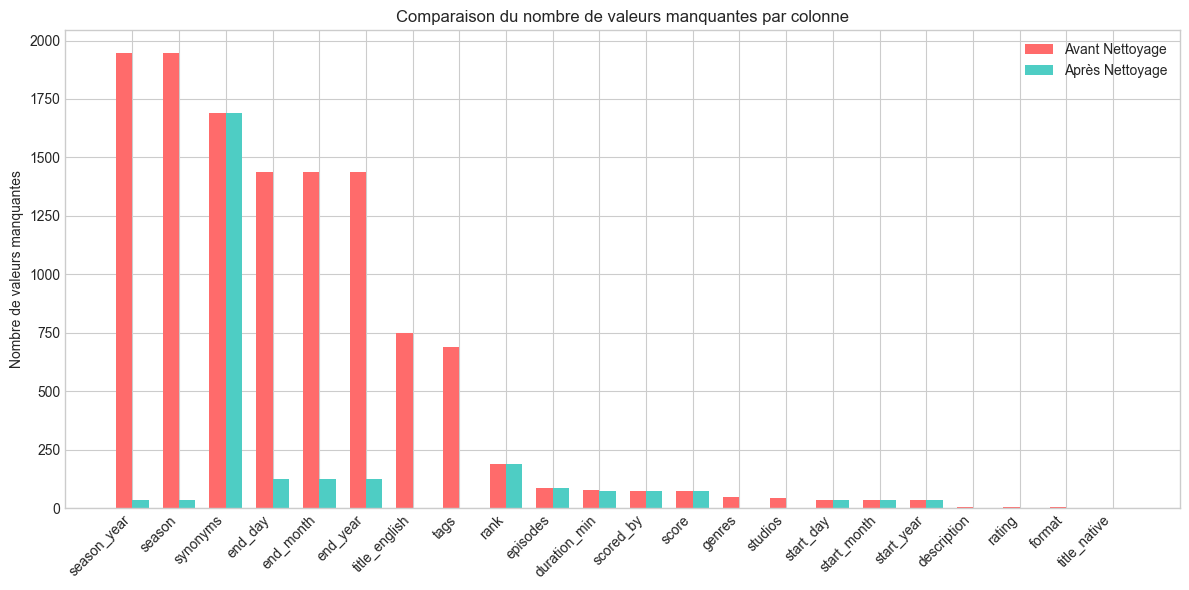

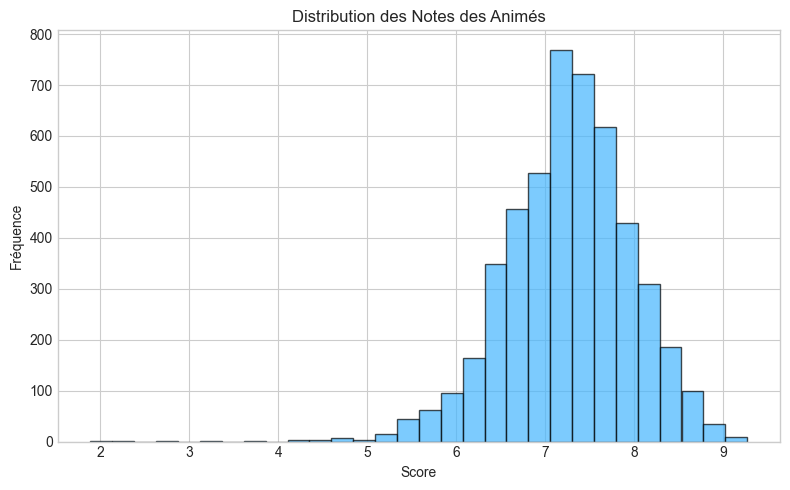

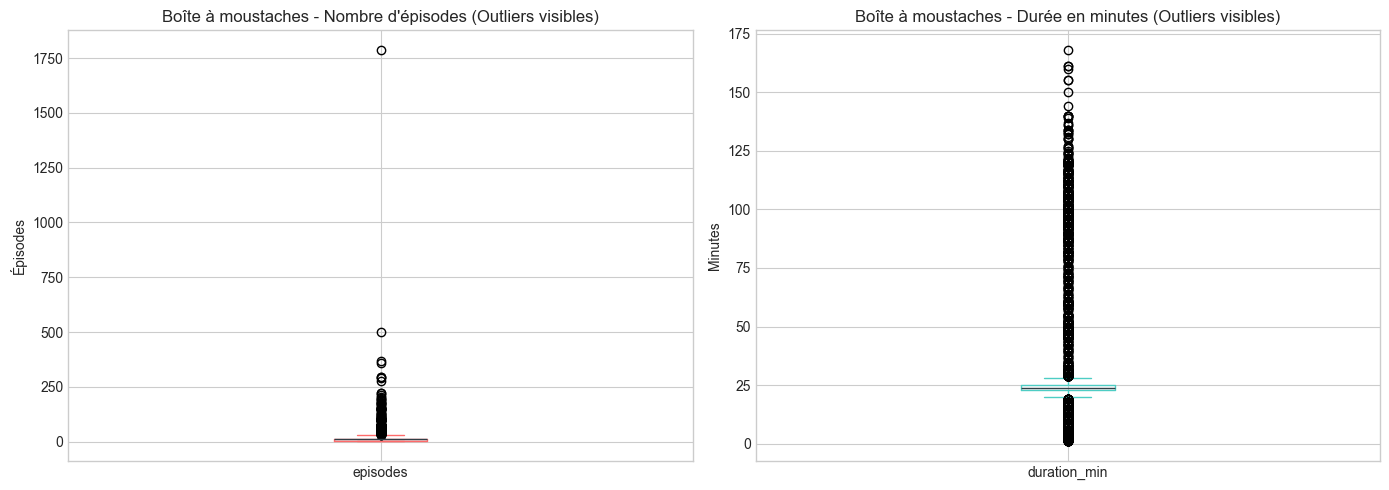

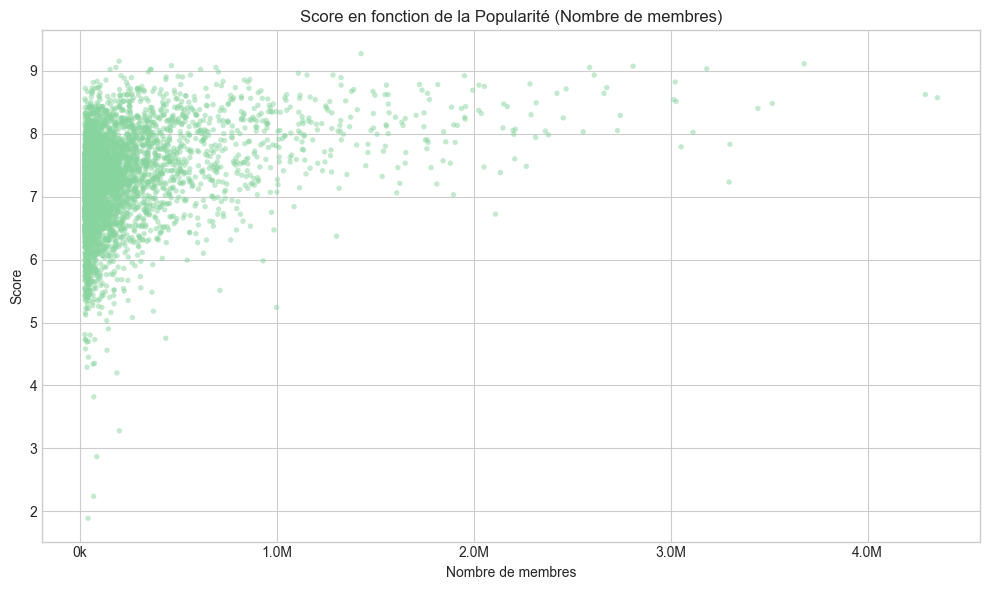

In [42]:
# Configuration du style des graphiques
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs("plots", exist_ok=True)

# Charger uniquement les colonnes requises pour la visualisation de la distribution (sans traitement)
df_clean_pd = df_clean.select("score", "episodes", "duration_min", "members").toPandas()

# 1. Comparaison des Valeurs Manquantes
fig, ax = plt.subplots(figsize=(12, 6))
# fusionner les deux dataframes de valeurs manquantes
comparison = pd.merge(missing_df, missing_df_clean, on="Colonne", how="outer").fillna(0)
comparison = comparison.sort_values(by="Valeurs Manquantes", ascending=False)

x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison["Valeurs Manquantes"], width, label='Avant Nettoyage', color='#ff6b6b')
ax.bar(x + width/2, comparison["Valeurs Manquantes Post-Clean"], width, label='Après Nettoyage', color='#4ecdc4')

ax.set_ylabel('Nombre de valeurs manquantes')
ax.set_title('Comparaison du nombre de valeurs manquantes par colonne')
ax.set_xticks(x)
ax.set_xticklabels(comparison["Colonne"], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig("plots/missing_values_comparison.png", dpi=150)
plt.show()

# 2. Distribution des Scores
fig, ax = plt.subplots(figsize=(8, 5))
df_clean_pd['score'].plot(kind='hist', bins=30, color='#45b6fe', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Distribution des Notes des Animés')
ax.set_xlabel('Score')
ax.set_ylabel('Fréquence')
plt.tight_layout()
plt.savefig("plots/score_distribution.png", dpi=150)
plt.show()

# 3. Boxplots des épisodes et durées (détection visuelle des outliers)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot Episodes
df_clean_pd.boxplot(column='episodes', ax=axes[0], color=dict(boxes='#ff6b6b', whiskers='#ff6b6b', medians='#2f3e46', caps='#ff6b6b'))
axes[0].set_title("Boîte à moustaches - Nombre d'épisodes (Outliers visibles)")
axes[0].set_ylabel("Épisodes")

# Boxplot Duration
df_clean_pd.boxplot(column='duration_min', ax=axes[1], color=dict(boxes='#4ecdc4', whiskers='#4ecdc4', medians='#2f3e46', caps='#4ecdc4'))
axes[1].set_title("Boîte à moustaches - Durée en minutes (Outliers visibles)")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.savefig("plots/outliers_boxplots.png", dpi=150)
plt.show()

# 4. Dispersion Score vs Members (Popularité)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_clean_pd['members'], df_clean_pd['score'], alpha=0.5, color='#88d49e', edgecolor='none', s=15)
ax.set_title('Score en fonction de la Popularité (Nombre de membres)')
ax.set_xlabel('Nombre de membres')
ax.set_ylabel('Score')
# Formater l'axe x pour une lecture plus facile (ex: 1M au lieu de 1000000)
import matplotlib.ticker as ticker
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x*1e-3:.0f}k'))
plt.tight_layout()
plt.savefig("plots/score_vs_popularity.png", dpi=150)
plt.show()

## 6. Analyses statistiques complémentaires : Genres et Popularité

Pour répondre aux questions d'analyse plus poussées, nous étudions ici la structure des genres et de leur popularité :
1. **Genres les plus populaires globalement** : Classement des 10 genres ayant réuni le plus grand nombre de membres.
2. **Évolution de la popularité (membres) des 5 genres majeurs** : Suivi de 2000 à 2025 pour observer l'attractivité des genres au fil du temps.
3. **Évolution du volume de sorties des 5 genres majeurs** : Suivi de 2000 à 2025 du nombre de productions par genre.
4. **Top 3 des genres par décennie** : Analyse historique des tendances de genres des années 1980 à nos jours.

Nous utilisons **PySpark** pour la manipulation/l'explosion des données et **Matplotlib** pour les tracés.


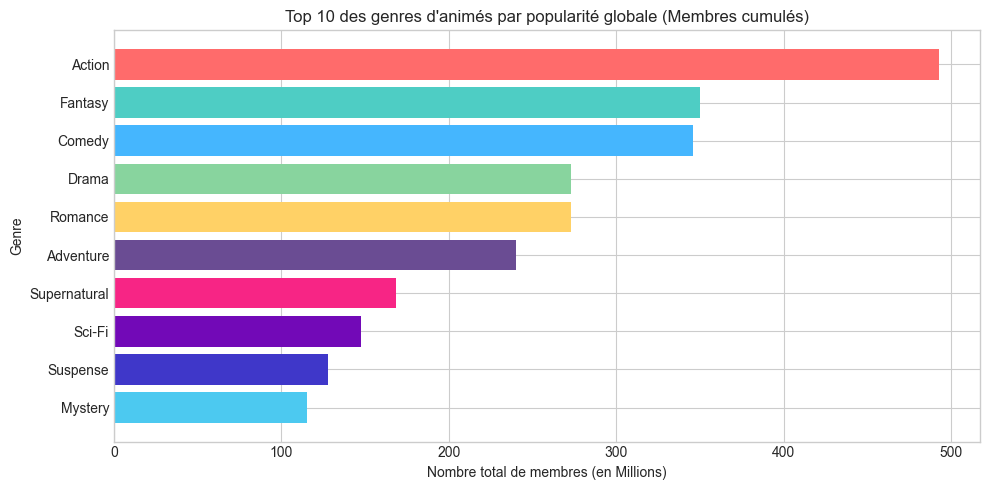

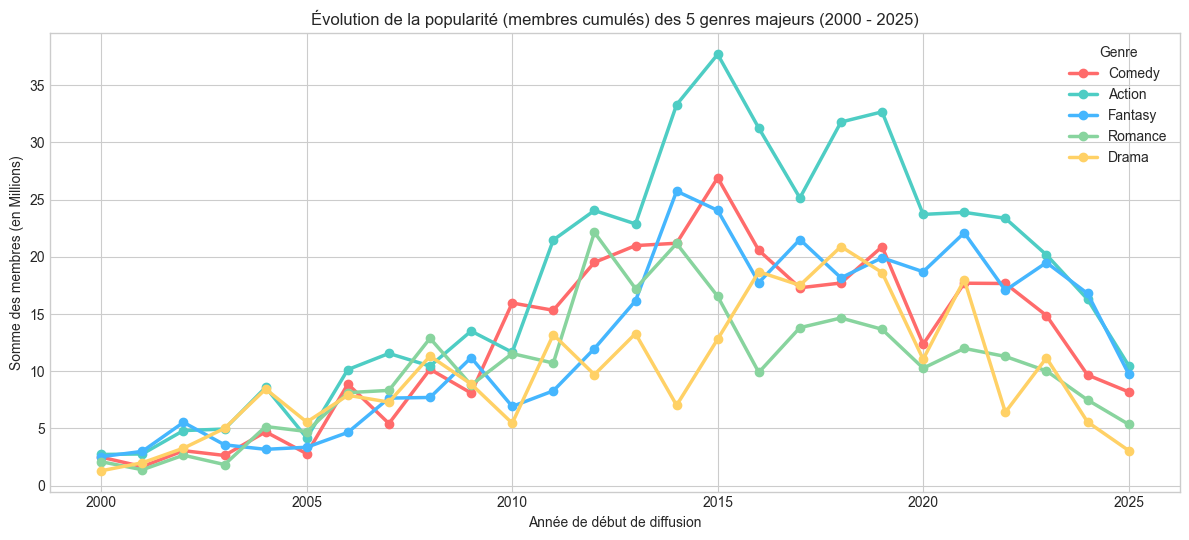

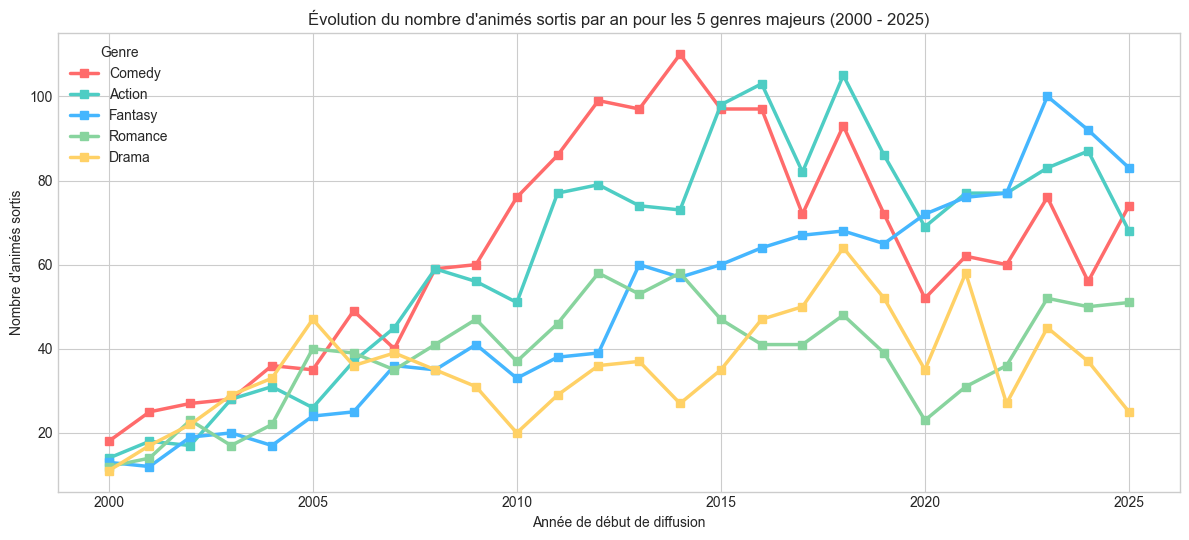

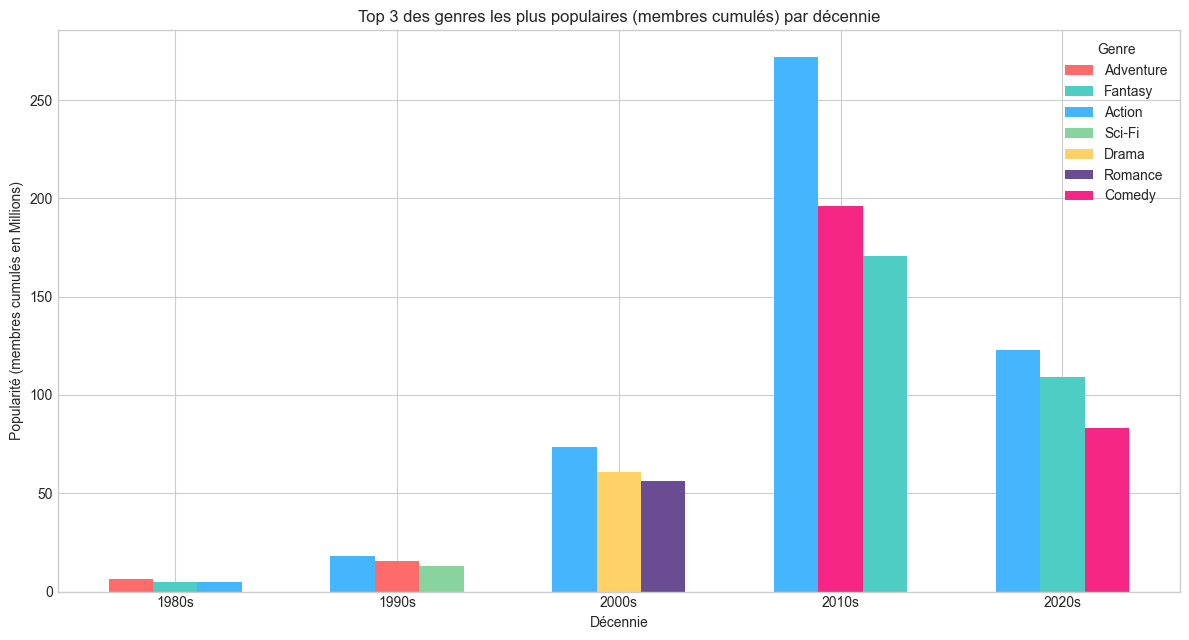

In [43]:
# 1. Explosion de la colonne 'genres' pour avoir une ligne par genre par animé
df_genres = df_clean.withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))

# Filtrer les genres invalides ou inconnus
df_genres = df_genres.filter((F.col("genre") != "Unknown") & (F.col("genre").isNotNull()) & (F.col("genre") != ""))

# Palette de couleurs personnalisées pour des graphiques esthétiques
colors = ['#ff6b6b', '#4ecdc4', '#45b6fe', '#88d49e', '#ffd166', '#6a4c93', '#f72585', '#7209b7', '#3f37c9', '#4cc9f0']

# --- Graphique 1 : Top 10 des genres par popularité cumulée (Membres) ---
# Traitement effectué entièrement en PySpark
top_genres_members_spark = df_genres.groupBy("genre").agg(F.sum("members").alias("total_members")) \
                                     .orderBy(F.col("total_members").desc()).limit(10)
# Seul le résultat final agrégé est converti pour l'affichage (10 lignes)
top_genres_members = top_genres_members_spark.toPandas().set_index("genre")["total_members"]

plt.figure(figsize=(10, 5))
plt.barh(top_genres_members.index[::-1], top_genres_members.values[::-1] / 1e6, color=colors[:10][::-1])
plt.title("Top 10 des genres d'animés par popularité globale (Membres cumulés)")
plt.xlabel("Nombre total de membres (en Millions)")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("plots/top_genres_global.png", dpi=150)
plt.show()


# --- Graphique 2 : Évolution de la popularité (membres) des 5 genres majeurs (2000 - 2025) ---
# Traitement effectué entièrement en PySpark
top_5_genres_spark = df_genres.groupBy("genre").count() \
                               .orderBy(F.col("count").desc()).limit(5)
top_5_genres = [row['genre'] for row in top_5_genres_spark.select("genre").collect()]

df_filtered_spark = df_genres.filter(
    (F.col("genre").isin(top_5_genres)) & 
    (F.col("start_year") >= 2000) & 
    (F.col("start_year") <= 2025)
)

evolution_members_spark = df_filtered_spark.groupBy("start_year", "genre").agg(F.sum("members").alias("members")) \
                                           .orderBy("start_year", "genre")
# Seul le résultat final agrégé est converti pour l'affichage
evolution_members = evolution_members_spark.toPandas()

plt.figure(figsize=(12, 5.5))
for i, genre in enumerate(top_5_genres):
    genre_data = evolution_members[evolution_members["genre"] == genre]
    plt.plot(genre_data["start_year"], genre_data["members"] / 1e6, marker='o', linewidth=2.5, label=genre, color=colors[i])
plt.title("Évolution de la popularité (membres cumulés) des 5 genres majeurs (2000 - 2025)")
plt.xlabel("Année de début de diffusion")
plt.ylabel("Somme des membres (en Millions)")
plt.legend(title="Genre")
plt.tight_layout()
plt.savefig("plots/genre_evolution_popularity.png", dpi=150)
plt.show()


# --- Graphique 3 : Évolution du nombre de sorties d'animés par an pour les 5 genres majeurs (2000 - 2025) ---
# Traitement effectué entièrement en PySpark
evolution_count_spark = df_filtered_spark.groupBy("start_year", "genre").count() \
                                         .withColumnRenamed("count", "title_romaji") \
                                         .orderBy("start_year", "genre")
# Seul le résultat final agrégé est converti pour l'affichage
evolution_count = evolution_count_spark.toPandas()

plt.figure(figsize=(12, 5.5))
for i, genre in enumerate(top_5_genres):
    genre_data = evolution_count[evolution_count["genre"] == genre]
    plt.plot(genre_data["start_year"], genre_data["title_romaji"], marker='s', linewidth=2.5, label=genre, color=colors[i])
plt.title("Évolution du nombre d'animés sortis par an pour les 5 genres majeurs (2000 - 2025)")
plt.xlabel("Année de début de diffusion")
plt.ylabel("Nombre d'animés sortis")
plt.legend(title="Genre")
plt.tight_layout()
plt.savefig("plots/genre_evolution_count.png", dpi=150)
plt.show()


# --- Graphique 4 : Les genres les plus populaires par décennie (Top 3) ---
# Traitement effectué entièrement en PySpark (y compris la décennie et le fenêtrage)
df_genres_decade = df_genres.withColumn("decade", 
    F.when(F.col("start_year").isNull(), "Unknown")
     .otherwise(F.concat((F.floor(F.col("start_year") / 10) * 10).cast("int"), F.lit("s")))
)

decades_to_plot = ["1980s", "1990s", "2000s", "2010s", "2020s"]
df_decades_spark = df_genres_decade.filter(F.col("decade").isin(decades_to_plot))

# Groupby et somme des membres
decade_genres_spark = df_decades_spark.groupBy("decade", "genre").agg(F.sum("members").alias("members"))

# Top 3 par décennie en utilisant une fonction de fenêtrage Spark
from pyspark.sql.window import Window
windowSpec = Window.partitionBy("decade").orderBy(F.col("members").desc())
top_decade_genres_spark = decade_genres_spark.withColumn("rank", F.row_number().over(windowSpec)) \
                                             .filter(F.col("rank") <= 3) \
                                             .orderBy("decade", F.col("members").desc())

# Seul le résultat final agrégé est converti pour l'affichage (15 lignes au maximum)
top_decade_genres = top_decade_genres_spark.toPandas()

fig, ax = plt.subplots(figsize=(12, 6.5))
decades = sorted(top_decade_genres["decade"].unique())
genres = top_decade_genres["genre"].unique()
genre_colors = {genre: colors[k % len(colors)] for k, genre in enumerate(genres)}
x = np.arange(len(decades))
width = 0.2

for i, decade in enumerate(decades):
    decade_data = top_decade_genres[top_decade_genres["decade"] == decade]
    for j, (_, row) in enumerate(decade_data.iterrows()):
        genre = row["genre"]
        val = row["members"] / 1e6
        bar_pos = i + (j - 1) * width
        ax.bar(bar_pos, val, width, color=genre_colors[genre], label=genre if f"{genre}_label" not in ax.get_legend_handles_labels()[1] else "")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Genre")
ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_title("Top 3 des genres les plus populaires (membres cumulés) par décennie")
ax.set_xlabel("Décennie")
ax.set_ylabel("Popularité (membres cumulés en Millions)")
plt.tight_layout()
plt.savefig("plots/top_genres_by_decade.png", dpi=150)
plt.show()

## 7. Indice de Silhouette — Nombre de clusters optimal (KMeans)

Avant de lancer le clustering, on construit les features qui décrivent le **contenu** de chaque animé :

- `genres` → encodage multi-hot (une colonne binaire par genre)
- `format`, `rating`, `source` → encodage one-hot
- `score`, `episodes` → colonnes numériques normalisées

On utilise ensuite l'**indice de silhouette** pour trouver le nombre de clusters `k` optimal.

Lignes disponibles pour le clustering : 4838
Genres uniques : 21
Top 50 tags retenus : ['Adult Cast', 'Anthropomorphic', 'CGDCT', 'Childcare', 'Crossdressing', 'Delinquents', 'Detective', 'Gag Humor', 'Gore', 'Harem', 'High Stakes Game', 'Historical', 'Idols (Female)', 'Isekai', 'Iyashikei', 'Josei', 'Kids', 'Love Polygon', 'Love Status Quo', 'Mahou Shoujo', 'Martial Arts', 'Mecha', 'Military', 'Music', 'Mythology', 'Organized Crime', 'Otaku Culture', 'Parody', 'Performing Arts', 'Psychological', 'Racing', 'Reincarnation', 'Reverse Harem', 'Samurai', 'School', 'Seinen', 'Shoujo', 'Shounen', 'Showbiz', 'Space', 'Strategy Game', 'Super Power', 'Survival', 'Team Sports', 'Time Travel', 'Urban Fantasy', 'Vampire', 'Video Game', 'Visual Arts', 'Workplace']
Vecteur de features : 76 dimensions
  k= 2  ->  silhouette = 0.0920
  k= 3  ->  silhouette = 0.0558
  k= 4  ->  silhouette = 0.0671
  k= 5  ->  silhouette = 0.0656
  k= 6  ->  silhouette = 0.0379
  k= 7  ->  silhouette = 0.0419
  k= 8  ->

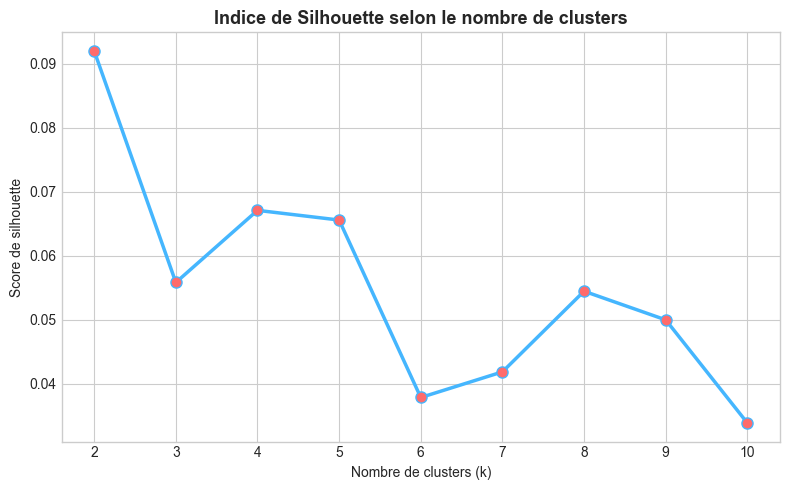


k optimal retenu : 2 (silhouette = 0.0920)


In [44]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

# ── 1. Sélection et nettoyage des colonnes utiles ────────────────────────────
df_ml = df_clean.select(
    "mal_id", "title_romaji", "genres", "tags", "score", "episodes", "format", "rating", "source"
).dropna(subset=["score", "episodes", "format", "rating", "source", "genres"]) \
 .filter(F.col("genres") != "Unknown")

print(f"Lignes disponibles pour le clustering : {df_ml.count()}")

# ── 2. Multi-hot encoding des genres ─────────────────────────────────────────
all_genres_list = (
    df_ml.withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))
         .select("genre").distinct()
         .filter(F.col("genre") != "")
         .collect()
)
all_genres = sorted([row['genre'] for row in all_genres_list])
print(f"Genres uniques : {len(all_genres)}")

for genre in all_genres:
    col_name = "g_" + genre.replace(" ", "_").replace("-", "_").replace("'", "")
    df_ml = df_ml.withColumn(col_name, F.when(F.col("genres").contains(genre), 1.0).otherwise(0.0))

genre_feature_cols = ["g_" + g.replace(" ", "_").replace("-", "_").replace("'", "") for g in all_genres]

# ── 3. Multi-hot encoding des tags (top 50 les plus fréquents) ───────────────
# On limite aux 50 tags les plus fréquents pour éviter l'explosion de la dimensionnalité
top_tags = (
    df_ml.filter((F.col("tags") != "Unknown") & F.col("tags").isNotNull())
         .withColumn("tag", F.explode(F.split(F.col("tags"), "\\|")))
         .filter(F.col("tag") != "")
         .groupBy("tag").count()
         .orderBy(F.col("count").desc())
         .limit(50)
         .select("tag").collect()
)
top_tags_list = sorted([row['tag'] for row in top_tags])
print(f"Top 50 tags retenus : {top_tags_list}")

for tag in top_tags_list:
    col_name = "t_" + tag.replace(" ", "_").replace("-", "_").replace("'", "")
    df_ml = df_ml.withColumn(col_name,
        F.when(F.col("tags").isNotNull() & F.col("tags").contains(tag), 1.0).otherwise(0.0)
    )

tag_feature_cols = ["t_" + t.replace(" ", "_").replace("-", "_").replace("'", "") for t in top_tags_list]
# ─────────────────────────────────────────────────────────────────────────────

# ── 4. One-hot encoding des colonnes catégorielles ────────────────────────────
cat_cols = ["format", "rating", "source"]
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx" for c in cat_cols], outputCols=[f"{c}_ohe" for c in cat_cols])]
pipeline = Pipeline(stages=indexers + encoders)
df_ml = pipeline.fit(df_ml).transform(df_ml)
ohe_cols = [f"{c}_ohe" for c in cat_cols]

# ── 5. Normalisation log des épisodes ────────────────────────────────────────
df_ml = df_ml.withColumn("log_episodes", F.log1p(F.col("episodes")))
numeric_cols = ["score", "log_episodes"]

# ── 6. Assemblage et standardisation ─────────────────────────────────────────
all_feature_cols = numeric_cols + genre_feature_cols + tag_feature_cols + ohe_cols
df_assembled = VectorAssembler(inputCols=all_feature_cols, outputCol="features_raw", handleInvalid="skip") \
                   .transform(df_ml)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=False)
df_scaled = scaler.fit(df_assembled).transform(df_assembled).select("mal_id", "title_romaji", "features")
df_scaled.cache()
print(f"Vecteur de features : {len(all_feature_cols)} dimensions")

# ── 7. Silhouette pour k=2 à 10 ──────────────────────────────────────────────
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(featuresCol="features", k=k, seed=42, maxIter=20).fit(df_scaled)
    sil = evaluator.evaluate(model.transform(df_scaled))
    silhouette_scores.append((k, sil))
    print(f"  k={k:2d}  ->  silhouette = {sil:.4f}")

df_scaled.unpersist()

ks   = [x[0] for x in silhouette_scores]
sils = [x[1] for x in silhouette_scores]

plt.figure(figsize=(8, 5))
plt.plot(ks, sils, marker='o', linewidth=2.5, color='#45b6fe', markerfacecolor='#ff6b6b', markersize=8)
plt.title("Indice de Silhouette selon le nombre de clusters", fontsize=13, fontweight='bold')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.xticks(ks)
plt.tight_layout()
plt.savefig("plots/silhouette_scores.png", dpi=150)
plt.show()

best_k, best_sil = max(silhouette_scores, key=lambda x: x[1])
print(f"\nk optimal retenu : {best_k} (silhouette = {best_sil:.4f})")


## 8. Clustering KMeans (k=4)

On applique KMeans avec `k=4` (retenu via l'indice de silhouette) sur les features construites à l'étape précédente.
On profile ensuite chaque cluster pour comprendre ce qu'il représente.

KMeans appliqué avec k=4

Répartition des animés par cluster :
+-------+-----+
|cluster|count|
+-------+-----+
|      0| 2197|
|      1| 2504|
|      2|   76|
|      3|   61|
+-------+-----+

Profil numérique par cluster :
+-------+---------+-----------+--------------+
|cluster|nb_animes|score_moyen|episodes_moyen|
+-------+---------+-----------+--------------+
|      0|     2197|       7.29|          13.3|
|      1|     2504|       7.24|          13.4|
|      2|       76|       7.08|          59.9|
|      3|       61|       6.78|           4.3|
+-------+---------+-----------+--------------+

Top 5 genres par cluster :
+-------+---------+-----+----+
|cluster|genre    |count|rank|
+-------+---------+-----+----+
|0      |Action   |1351 |1   |
|0      |Fantasy  |948  |2   |
|0      |Adventure|787  |3   |
|0      |Sci-Fi   |649  |4   |
|0      |Drama    |579  |5   |
|1      |Comedy   |1427 |1   |
|1      |Romance  |895  |2   |
|1      |Drama    |451  |3   |
|1      |Ecchi    |402  |4   |
|

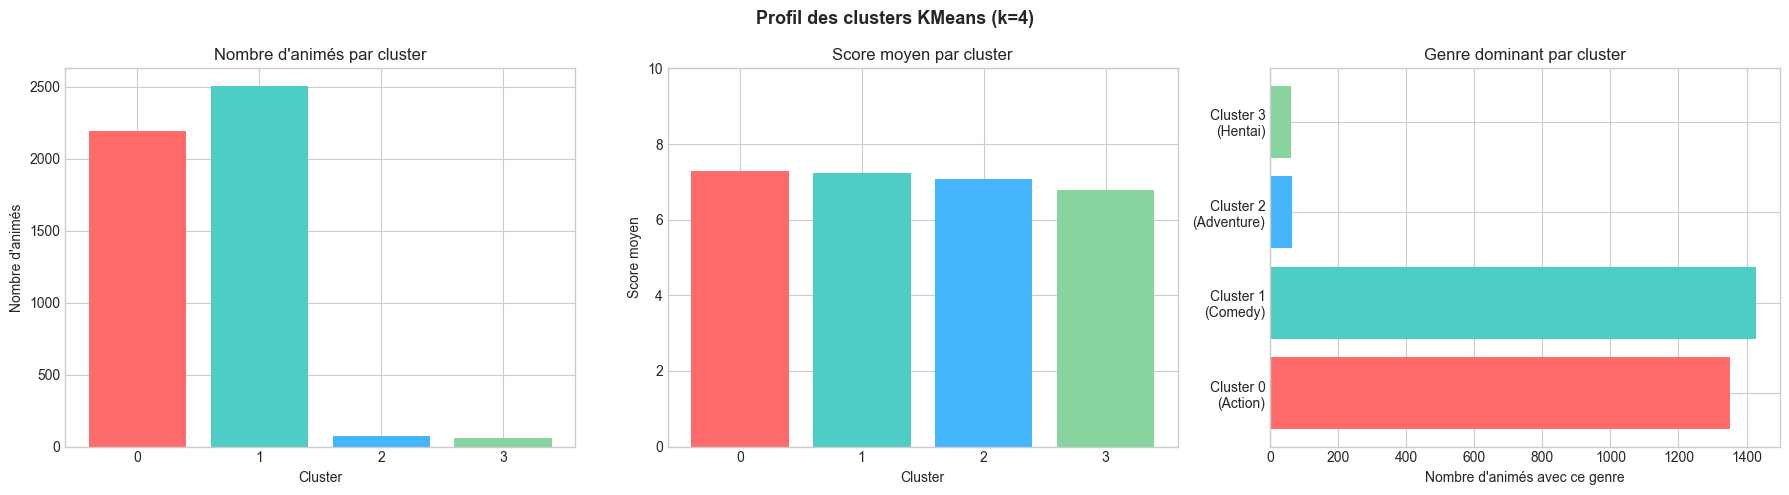

In [45]:
from pyspark.sql.window import Window

# ── 1. Reconstruction du vecteur de features (depuis df_ml déjà préparé) ──────
df_assembled_k = VectorAssembler(inputCols=all_feature_cols, outputCol="features_raw", handleInvalid="skip") \
                     .transform(df_ml)

scaler_model = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=False) \
                   .fit(df_assembled_k)
df_scaled_k = scaler_model.transform(df_assembled_k)

# ── 2. KMeans avec k=4 ────────────────────────────────────────────────────────
K_OPTIMAL = 4
kmeans_model = KMeans(featuresCol="features", k=K_OPTIMAL, seed=42, maxIter=50).fit(df_scaled_k)
df_clustered = kmeans_model.transform(df_scaled_k).withColumnRenamed("prediction", "cluster")
df_clustered.cache()

print(f"KMeans appliqué avec k={K_OPTIMAL}")
print("\nRépartition des animés par cluster :")
df_clustered.groupBy("cluster").count().orderBy("cluster").show()

# ── 3. Profil numérique de chaque cluster ────────────────────────────────────
df_profile = df_clustered.groupBy("cluster").agg(
    F.count("*").alias("nb_animes"),
    F.round(F.avg("score"), 2).alias("score_moyen"),
    F.round(F.avg("episodes"), 1).alias("episodes_moyen")
).orderBy("cluster")

print("Profil numérique par cluster :")
df_profile.show()

# ── 4. Top 5 genres par cluster ───────────────────────────────────────────────
top_genres_cluster = (
    df_clustered.select("cluster", "genres")
    .withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))
    .filter((F.col("genre") != "") & (F.col("genre") != "Unknown"))
    .groupBy("cluster", "genre").count()
    .withColumn("rank", F.row_number().over(Window.partitionBy("cluster").orderBy(F.col("count").desc())))
    .filter(F.col("rank") <= 5)
    .orderBy("cluster", "rank")
)

print("Top 5 genres par cluster :")
top_genres_cluster.show(20, truncate=False)

# ── 5. Visualisation des profils de clusters ──────────────────────────────────
colors = ['#ff6b6b', '#4ecdc4', '#45b6fe', '#88d49e']
profile_pd  = df_profile.toPandas()
sizes_pd    = df_clustered.groupBy("cluster").count().orderBy("cluster").toPandas()
genres_pd   = top_genres_cluster.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Taille des clusters
axes[0].bar(sizes_pd["cluster"].astype(str), sizes_pd["count"], color=colors)
axes[0].set_title("Nombre d'animés par cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Nombre d'animés")

# Score moyen par cluster
axes[1].bar(profile_pd["cluster"].astype(str), profile_pd["score_moyen"], color=colors)
axes[1].set_title("Score moyen par cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Score moyen")
axes[1].set_ylim(0, 10)

# Top genre dominant par cluster
top1 = genres_pd[genres_pd["rank"] == 1]
axes[2].barh(top1["cluster"].astype(str), top1["count"], color=colors)
axes[2].set_yticks(range(K_OPTIMAL))
axes[2].set_yticklabels([f"Cluster {c}\n({g})" for c, g in zip(top1["cluster"], top1["genre"])])
axes[2].set_title("Genre dominant par cluster")
axes[2].set_xlabel("Nombre d'animés avec ce genre")

plt.suptitle("Profil des clusters KMeans (k=4)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/clusters_profile.png", dpi=150)
plt.show()


### Visualisation PCA 2D

Pour visualiser les clusters, on projette les features (70+ dimensions) en **2 dimensions** via PCA. Chaque point représente un animé, chaque couleur un cluster.

In [ ]:
from pyspark.ml.feature import PCA

# ── Visualisation PCA 2D des clusters ────────────────────────────────────────
# On réduit les features à 2 dimensions pour pouvoir les afficher sur un graphique.
# Chaque point = un animé, chaque couleur = un cluster.

# 1. Réduction en 2 composantes via PCA
pca_2d_model = PCA(k=2, inputCol="features", outputCol="pca_coords").fit(df_scaled_k)
df_pca2d = pca_2d_model.transform(df_scaled_k).select("mal_id", "pca_coords")

# 2. Joindre avec les clusters (mal_id comme clé)
pca_pd = (
    df_clustered.select("mal_id", "title_romaji", "cluster")
    .join(df_pca2d, on="mal_id", how="inner")
    .toPandas()
)
pca_pd["x"] = pca_pd["pca_coords"].apply(lambda v: float(v[0]))
pca_pd["y"] = pca_pd["pca_coords"].apply(lambda v: float(v[1]))

# 3. Graphique
colors = ['#ff6b6b', '#4ecdc4', '#45b6fe', '#88d49e']

fig, ax = plt.subplots(figsize=(10, 7))
for k in range(K_OPTIMAL):
    subset = pca_pd[pca_pd["cluster"] == k]
    ax.scatter(subset["x"], subset["y"], s=10, alpha=0.5, color=colors[k], label=f"Cluster {k}")

ax.set_title("Visualisation des clusters en 2D (PCA)", fontsize=13, fontweight='bold')
ax.set_xlabel("Composante principale 1")
ax.set_ylabel("Composante principale 2")
ax.legend(title="Cluster", markerscale=3)
plt.tight_layout()
plt.savefig("plots/clusters_pca2d.png", dpi=150)
plt.show()


In [46]:
# ── Description automatique de chaque cluster ─────────────────────────────────
# Pour chaque cluster on récupère : top 3 genres, score moyen,
# épisodes moyens et format dominant → on construit un label lisible.

# Top 3 genres par cluster
top3_genres = (
    df_clustered.select("cluster", "genres")
    .withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))
    .filter((F.col("genre") != "") & (F.col("genre") != "Unknown"))
    .groupBy("cluster", "genre").count()
    .withColumn("rank", F.row_number().over(Window.partitionBy("cluster").orderBy(F.col("count").desc())))
    .filter(F.col("rank") <= 3)
    .orderBy("cluster", "rank")
    .toPandas()
)

# Format dominant par cluster
top_format = (
    df_clustered.groupBy("cluster", "format").count()
    .withColumn("rank", F.row_number().over(Window.partitionBy("cluster").orderBy(F.col("count").desc())))
    .filter(F.col("rank") == 1)
    .select("cluster", "format")
    .toPandas()
)

# Profil numérique
profile_desc = df_profile.toPandas()

# Construction des descriptions
print("=" * 60)
print("DESCRIPTION DES CLUSTERS")
print("=" * 60)

for cluster_id in sorted(profile_desc["cluster"].unique()):
    genres_c  = top3_genres[top3_genres["cluster"] == cluster_id]["genre"].tolist()
    format_c  = top_format[top_format["cluster"] == cluster_id]["format"].values[0]
    row       = profile_desc[profile_desc["cluster"] == cluster_id].iloc[0]

    print(f"\n Cluster {cluster_id}")
    print(f"   Nombre d'animés  : {int(row['nb_animes'])}")
    print(f"   Format dominant  : {format_c}")
    print(f"   Score moyen      : {row['score_moyen']}")
    print(f"   Épisodes moyens  : {row['episodes_moyen']}")
    print(f"   Top 3 genres     : {', '.join(genres_c)}")


DESCRIPTION DES CLUSTERS

 Cluster 0
   Nombre d'animés  : 2197
   Format dominant  : TV
   Score moyen      : 7.29
   Épisodes moyens  : 13.3
   Top 3 genres     : Action, Fantasy, Adventure

 Cluster 1
   Nombre d'animés  : 2504
   Format dominant  : TV
   Score moyen      : 7.24
   Épisodes moyens  : 13.4
   Top 3 genres     : Comedy, Romance, Drama

 Cluster 2
   Nombre d'animés  : 76
   Format dominant  : Movie
   Score moyen      : 7.08
   Épisodes moyens  : 59.9
   Top 3 genres     : Adventure, Fantasy, Comedy

 Cluster 3
   Nombre d'animés  : 61
   Format dominant  : OVA
   Score moyen      : 6.78
   Épisodes moyens  : 4.3
   Top 3 genres     : Hentai, Comedy, Fantasy


## 9. Système de Recommandation

La fonction de recommandation fonctionne en 3 étapes :
1. **Trouver** l'animé dans le dataset et récupérer son cluster et son vecteur de features.
2. **Filtrer** tous les animés du même cluster.
3. **Trier** par distance Euclidienne sur les features — les plus proches sont les plus similaires.

In [47]:
# ── Fonction de recommandation ────────────────────────────────────────────────
def recommend_anime(title, n=10, exclude_franchise=True):
    """
    Recommande les n animés les plus similaires à l'animé donné.
    - title            : nom (partiel, insensible à la casse)
    - n                : nombre de recommandations
    - exclude_franchise: si True, exclut les animés dont le titre contient
                         le terme recherché (évite les saisons du même anime)
    """
    # 1. Recherche de l'animé dans le dataset
    match = (
        df_clustered
        .filter(F.lower(F.col("title_romaji")).contains(title.lower()))
        .select("title_romaji", "cluster", "features", "genres", "tags", "score", "episodes", "format")
        .first()
    )

    if match is None:
        print(f"Animé '{title}' introuvable. Vérifie l'orthographe.")
        return None

    cluster_id = match["cluster"]
    target_vec = np.array(match["features"].toArray())

    print("=" * 55)
    print(f" Animé sélectionné : {match['title_romaji']}")
    print(f" Cluster           : {cluster_id}")
    print(f" Genres            : {match['genres']}")
    print(f" Score             : {match['score']}  |  Épisodes : {match['episodes']}")
    print(f" Tags              : {match['tags']}")
    print(f" Exclusion franchise : {exclude_franchise}")
    print("=" * 55)

    # 2. Récupérer tous les animés du même cluster
    cluster_pd = (
        df_clustered
        .filter(F.col("cluster") == cluster_id)
        .select("title_romaji", "genres", "tags", "score", "episodes", "format", "features")
        .toPandas()
    )

    # 3. Calcul de la distance Euclidienne par rapport à l'animé cible
    cluster_pd["distance"] = cluster_pd["features"].apply(
        lambda v: np.linalg.norm(np.array(v.toArray()) - target_vec)
    )

    # 4. Exclusion de l'animé lui-même
    recs = cluster_pd[cluster_pd["title_romaji"] != match["title_romaji"]]

    # 5. Exclusion de la franchise si demandé
    if exclude_franchise:
        recs = recs[~recs["title_romaji"].str.lower().str.contains(title.lower())]

    # 6. Tri par distance croissante et sélection des N meilleurs
    recs = (
        recs.sort_values("distance")
        .head(n)
        [["title_romaji", "genres", "tags", "score", "episodes", "format"]]
        .reset_index(drop=True)
    )
    recs.index += 1

    print(f"\n Top {n} recommandations :")
    print(recs.to_string())
    return recs


# ── Exemples d'utilisation ────────────────────────────────────────────────────
recommend_anime("Shingeki no kyojin", n=10, exclude_franchise=True)


 Animé sélectionné : Shingeki no Kyojin
 Cluster           : 0
 Genres            : Action|Award Winning|Drama|Suspense
 Score             : 8.57  |  Épisodes : 25.0
 Tags              : Gore|Military|Survival|Shounen
 Exclusion franchise : True

 Top 10 recommandations :
                                          title_romaji                                           genres                            tags  score  episodes format
1                                Yakusoku no Neverland                                 Mystery|Suspense  Psychological|Survival|Shounen   8.47      12.0     TV
2                               Highschool of the Dead                     Action|Horror|Suspense|Ecchi           Gore|Survival|Shounen   7.06      12.0     TV
3   Zom 100: Zombie ni Naru made ni Shitai 100 no Koto                                  Comedy|Suspense      Adult Cast|Survival|Seinen   7.70      12.0     TV
4                                      Kanata no Astra  Adventure|Award Winning|Mystery

,title_romaji,genres,tags,score,episodes,format
1,Yakusoku no Neverland,Mystery|Suspense,Psychological|Survival|Shounen,8.47,12.0,TV
2,Highschool of the Dead,Action|Horror|Suspense|Ecchi,Gore|Survival|Shounen,7.06,12.0,TV
3,Zom 100: Zombie ni Naru made ni Shitai 100 no ...,Comedy|Suspense,Adult Cast|Survival|Seinen,7.70,12.0,TV
4,Kanata no Astra,Adventure|Award Winning|Mystery|Sci-Fi|Suspense,Space|Survival|Shounen,8.07,12.0,TV
5,Koutetsujou no Kabaneri,Action|Fantasy|Horror|Suspense,Gore|Historical|Survival,7.29,12.0,TV
6,Fullmetal Alchemist,Action|Adventure|Award Winning|Drama|Fantasy,Military|Shounen,8.12,51.0,TV
7,Nyaight of the Living Cat,Action|Horror|Suspense,Survival|Shounen,6.33,12.0,TV
8,Yakusoku no Neverland 2nd Season,Mystery|Suspense,Psychological|Survival|Shounen,5.24,11.0,TV
9,Koutetsujou no Kabaneri Movie 3: Unato Kessen,Action|Fantasy|Horror|Suspense,Gore|Historical|Survival,7.69,1.0,Movie
10,Koutetsujou no Kabaneri Movie 2: Moeru Inochi,Action|Fantasy|Horror|Suspense,Gore|Historical|Survival,7.59,1.0,Movie


## Conclusion

Ce notebook a couvert l'ensemble du pipeline de traitement et d'analyse du dataset anime avec **PySpark** :

### Nettoyage des données
- **Trous de données** : Réduits significativement — dates de fin propagées pour les formats à diffusion unique, durées imputées par la médiane du format, saisons recalculées depuis `start_month`, champs texte nuls remplacés.
- **Valeurs aberrantes** : L'incohérence de date pour *Bakugan* a été corrigée. Les outliers statistiques (*Doraemon*, films longs) ont été conservés car valides.

### Analyse statistique
- Statistiques descriptives globales (`describe`, percentiles, distributions catégorielles).
- Analyse des valeurs manquantes et aberrantes via la méthode IQR.
- Analyses par genres : top 10 genres, évolution temporelle, top genres par décennie.

### Visualisations
- Comparaison des valeurs manquantes avant/après nettoyage.
- Distribution des scores, boxplots des outliers, scatter score/popularité.
- Évolution de la popularité et du volume de sorties par genre.
- Visualisation PCA 2D des clusters.

### Machine Learning — Système de recommandation
- **Feature engineering** : multi-hot encoding des genres et top 50 tags, one-hot encoding de `format`/`rating`/`source`, normalisation log des épisodes.
- **Sélection du k** : indice de silhouette évalué pour k=2 à 10 → `k=4` retenu.
- **Clustering KMeans** (PySpark MLlib) : 4 clusters identifiés (contenu adulte/OVA, séries TV classiques, films et formats courts, séries longues).
- **Système de recommandation** : fonction `recommend_anime()` basée sur la distance Euclidienne intra-cluster, avec option `exclude_franchise` pour filtrer les saisons du même animé.
